# 3D Wireframe Visualization with Color Zones

This notebook creates a 3D wireframe plot with:
- Parallel cosine curves as the surface data
- Different colors for lines in different directions
- Color change at 60% through the z-axis (horizontal plane division)

In [61]:
import numpy as np
import matplotlib.pyplot as plt

# Enable interactive mode for matplotlib
%matplotlib widget

In [62]:
# Generate data for parallel cosine curves
x = np.linspace(-2, 2, 100)
y = np.linspace(-2, 2, 100)
X, Y = np.meshgrid(x, y)

# Create more diverse cosine curves - varying frequencies, phases, and amplitudes
Z = (
    np.cos(2 * np.pi * X) * (1 + 0.3 * Y)  # amplitude varies with Y
    + 0.6 * np.cos(1.5 * np.pi * Y + 0.5 * X)  # phase varies with X
    + 0.3 * np.sin(3 * X * Y)  # interaction term for complexity
)

print(f"Data shapes - X: {X.shape}, Y: {Y.shape}, Z: {Z.shape}")
print(f"Z range: {Z.min():.2f} to {Z.max():.2f}")

Data shapes - X: (100, 100), Y: (100, 100), Z: (100, 100)
Z range: -2.25 to 2.31


In [ ]:
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap
import numpy as np


def plot_data(X, Y, Z, z_split_pct=0.6):
    """
    Create a 3D wireframe plot with color zones split at a percentage of the z-axis.

    Parameters:
        X, Y, Z: 2D arrays from meshgrid defining the surface
        z_split_pct: percentage (0-1) along z-axis where color changes (default 0.6)
    """
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection="3d")

    # Calculate the z-axis split value
    z_min, z_max = Z.min(), Z.max()
    z_split_val = z_min + z_split_pct * (z_max - z_min)

    print(f"Z-axis range: {z_min:.2f} to {z_max:.2f}")
    print(f"{z_split_pct*100:.0f}% split point: z = {z_split_val:.2f}")

    # Define color pairs for each region (start_color, end_color)
    colors_x_below = ("#00BFFF", "#0000CD")  # sky blue -> medium blue
    colors_x_above = ("#FFD700", "#DC143C")  # yellow -> red
    colors_y_below = ("#7FFF00", "#006400")  # light green -> dark green
    colors_y_above = ("#FFA07A", "#FF4500")  # light orange -> dark orange

    def make_colormap(color1, color2):
        """Create a colormap that interpolates between two colors."""
        return LinearSegmentedColormap.from_list("custom", [color1, color2])

    cmap_x_below = make_colormap(*colors_x_below)
    cmap_x_above = make_colormap(*colors_x_above)
    cmap_y_below = make_colormap(*colors_y_below)
    cmap_y_above = make_colormap(*colors_y_above)

    def get_gradient_color(z_val, is_below, cmap_below, cmap_above):
        """Get color from gradient based on z position within region."""
        if is_below:
            t = (z_val - z_min) / (z_split_val - z_min) if z_split_val > z_min else 0.5
        else:
            t = (z_val - z_split_val) / (z_max - z_split_val) if z_max > z_split_val else 0.5
        t = np.clip(t, 0, 1)
        cmap = cmap_below if is_below else cmap_above
        return cmap(t)

    def plot_line_with_split(x_coords, y_coords, z_coords, cmap_below, cmap_above):
        """Plot a line with sharp color transition and gradients."""
        for i in range(len(x_coords) - 1):
            x0, x1 = x_coords[i], x_coords[i + 1]
            y0, y1 = y_coords[i], y_coords[i + 1]
            z0, z1 = z_coords[i], z_coords[i + 1]

            below_0 = z0 < z_split_val
            below_1 = z1 < z_split_val

            if below_0 == below_1:
                z_mid = (z0 + z1) / 2
                color = get_gradient_color(z_mid, below_0, cmap_below, cmap_above)
                ax.plot([x0, x1], [y0, y1], [z0, z1], color=color, linewidth=1.5, alpha=0.9)
            else:
                t = (z_split_val - z0) / (z1 - z0)
                x_cross = x0 + t * (x1 - x0)
                y_cross = y0 + t * (y1 - y0)
                z_cross = z_split_val

                if below_0:
                    color1 = get_gradient_color((z0 + z_cross) / 2, True, cmap_below, cmap_above)
                    color2 = get_gradient_color((z_cross + z1) / 2, False, cmap_below, cmap_above)
                else:
                    color1 = get_gradient_color((z0 + z_cross) / 2, False, cmap_below, cmap_above)
                    color2 = get_gradient_color((z_cross + z1) / 2, True, cmap_below, cmap_above)
                ax.plot([x0, x_cross], [y0, y_cross], [z0, z_cross], color=color1, linewidth=1.5, alpha=0.9)
                ax.plot([x_cross, x1], [y_cross, y1], [z_cross, z1], color=color2, linewidth=1.5, alpha=0.9)

    # Plot X-direction lines (rows)
    for i in range(X.shape[0]):
        plot_line_with_split(X[i, :], Y[i, :], Z[i, :], cmap_x_below, cmap_x_above)

    # Plot Y-direction lines (columns)
    for j in range(X.shape[1]):
        plot_line_with_split(X[:, j], Y[:, j], Z[:, j], cmap_y_below, cmap_y_above)

    # Add labels and title
    ax.set_xlabel("X Axis", fontsize=12)
    ax.set_ylabel("Y Axis", fontsize=12)
    ax.set_zlabel("Z Axis", fontsize=12)
    ax.set_title(
        f"3D Wireframe with Gradient Colors\nColor split at {z_split_pct*100:.0f}% Z-axis",
        fontsize=14,
        pad=20,
    )

    # Add a horizontal plane indicator at the split point
    x_range = [X.min(), X.max()]
    y_range = [Y.min(), Y.max()]
    plane_x = np.array([[x_range[0], x_range[0]], [x_range[1], x_range[1]]])
    plane_y = np.array([[y_range[0], y_range[1]], [y_range[0], y_range[1]]])
    plane_z = np.array([[z_split_val, z_split_val], [z_split_val, z_split_val]])
    ax.plot_surface(plane_x, plane_y, plane_z, alpha=0.15, color="gray")

    # Add legend showing gradient endpoints
    legend_elements = [
        Line2D([0], [0], color=colors_x_below[0], lw=2, marker="o", markersize=4,
               markerfacecolor=colors_x_below[1], label="X below"),
        Line2D([0], [0], color=colors_x_above[0], lw=2, marker="o", markersize=4,
               markerfacecolor=colors_x_above[1], label="X above"),
        Line2D([0], [0], color=colors_y_below[0], lw=2, marker="o", markersize=4,
               markerfacecolor=colors_y_below[1], label="Y below"),
        Line2D([0], [0], color=colors_y_above[0], lw=2, marker="o", markersize=4,
               markerfacecolor=colors_y_above[1], label="Y above"),
        Line2D([0], [0], color="gray", lw=2, alpha=0.3, label=f"{z_split_pct*100:.0f}% Z split plane"),
    ]
    ax.legend(handles=legend_elements, loc="upper left", fontsize=9)

    # Set viewing angle
    ax.view_init(elev=25, azim=45)

    plt.tight_layout()
    plt.show()

    return fig, ax


print("plot_data function defined.")

plot_data function defined.


Z-axis range: -2.25 to 2.31
60% split point: z = 0.49


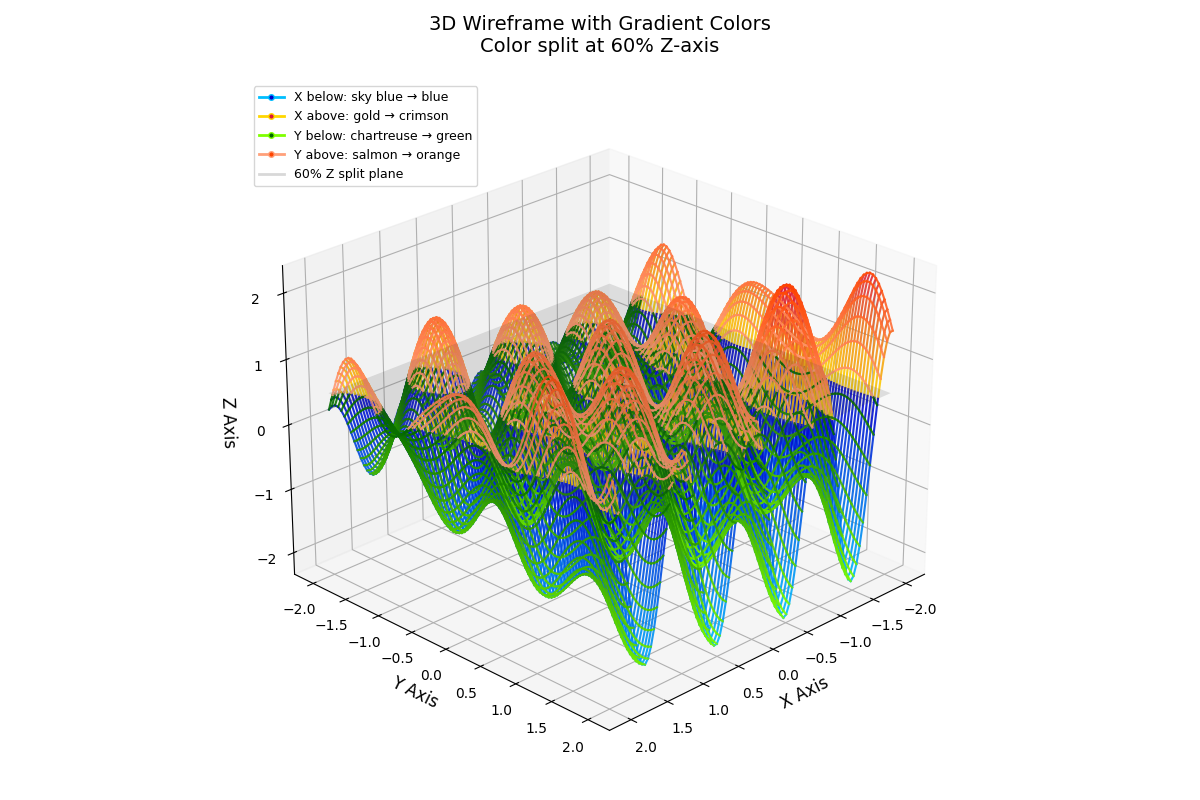

Plot displayed.


In [64]:
# Call the plotting function with our data
fig, ax = plot_data(X, Y, Z)

print("Plot displayed.")